# ⚡ Batch Calls vs Single Calls — OpenAI API Deep-Dive
## Measure, Compare & Optimize Your API Usage with GPT-4o-mini

**What you'll learn:**
- Single-call vs async-parallel vs OpenAI Batch API — architecture & trade-offs
- Wall-clock time, throughput, cost, and token-efficiency benchmarks
- Practical patterns: batching embeddings, chat completions, and mixed workloads
- Error handling, retry logic & rate-limit strategies for each mode

**Models used:** `gpt-4o-mini` (chat) · `text-embedding-3-small` (embeddings)

---
> 🔑 Run the setup cell first. All benchmarks use the **same prompts** so results are directly comparable.
> Costs are *estimated* from published per-token pricing.

In [1]:
# ============================================================
# 📦  SETUP & DEPENDENCIES
# ============================================================
!pip install openai tiktoken aiohttp nest_asyncio rich numpy tqdm -q

import os, json, time, asyncio, random, uuid, math, textwrap
from getpass import getpass
from datetime import datetime
from collections import defaultdict

import numpy as np
import tiktoken
from tqdm.notebook import tqdm
from rich.console import Console
from rich.table import Table
from IPython.display import display, HTML, Markdown as IPyMd

# Colab's event-loop fix
import nest_asyncio
nest_asyncio.apply()

os.environ["OPENAI_API_KEY"] = getpass("🔑 Enter your OpenAI API key: ")

from openai import OpenAI, AsyncOpenAI

client      = OpenAI()
async_client = AsyncOpenAI()

MODEL       = "gpt-4o-mini"
EMBED_MODEL = "text-embedding-3-small"
console     = Console()

# Pricing (USD per 1K tokens — check for latest)
PRICING = {
    MODEL: {"input": 0.000150, "output": 0.000600},
    EMBED_MODEL: {"input": 0.000020, "output": 0.0},
}

def est_cost(model, prompt_tok, completion_tok=0):
    p = PRICING[model]
    return (prompt_tok / 1000) * p["input"] + (completion_tok / 1000) * p["output"]

enc = tiktoken.encoding_for_model(MODEL)

print("✅  Setup complete")
print(f"    Chat model       : {MODEL}")
print(f"    Embedding model  : {EMBED_MODEL}")

🔑 Enter your OpenAI API key: ··········
✅  Setup complete
    Chat model       : gpt-4o-mini
    Embedding model  : text-embedding-3-small


---
## 1️⃣  Understanding the Three Modes

| Mode | How it works | Latency | Cost | Rate-limit pressure |
|------|-------------|---------|------|-------------------|
| **Sequential (single)** | One request at a time, wait for response | 🐢 Highest | Standard | Low |
| **Async-parallel** | Fire N requests concurrently via `asyncio` | ⚡ Lowest wall-clock | Standard | ⚠️ High — can hit RPM / TPM limits |
| **Batch API** | Upload a JSONL file; OpenAI processes offline in ≤24 h | 🕐 Offline (hours) | **50 % cheaper** | None (offline queue) |

> **Rule of thumb:** Use *sequential* for interactive / small jobs, *async-parallel* for medium real-time workloads, and *Batch API* for large offline pipelines where latency doesn't matter.

In [2]:
# ============================================================
# 🗂️  BUILD A SHARED TEST SET
# ============================================================

TASK_POOL = [
    "Summarize the key benefits of microservices architecture in 2 sentences.",
    "Write a Python function to check if a string is a palindrome. Include docstring.",
    "Explain the CAP theorem to a product manager in 3 bullet points.",
    "List 5 creative names for a coffee shop that also sells books.",
    "What are the trade-offs between SQL and NoSQL databases? Be concise.",
    "Rewrite this sentence to be more professional: 'hey dude the deploy is broke again lol'.",
    "Generate a JSON schema for a User object with name, email, age, and roles.",
    "Explain gradient descent using a mountain-hiking analogy in 4 sentences.",
    "Write 3 unit-test names (pytest style) for a function calculate_discount(price, pct).",
    "Compare REST vs GraphQL in a markdown table with 4 criteria.",
    "Draft a one-paragraph OKR for an engineering team focused on API reliability.",
    "Explain Docker containers vs VMs to a junior developer. Keep it under 80 words.",
    "Write a SQL query to find the top 5 customers by total order value.",
    "Give 3 prompt-engineering tips for getting consistent JSON from an LLM.",
    "Describe the Observer design pattern with a real-world analogy.",
    "Write a haiku about debugging production at 2 AM.",
    "Explain the difference between authentication and authorization in 3 sentences.",
    "Create a regex pattern that validates email addresses and explain each part.",
    "What is eventual consistency? Explain with a social-media example.",
    "Write a commit message for fixing a race condition in the payment service.",
]

EMBED_TEXTS = [
    "Machine learning model training and optimization techniques",
    "Cloud infrastructure scaling with Kubernetes and Docker",
    "Natural language processing for sentiment analysis",
    "Database indexing strategies for high-throughput applications",
    "Frontend performance optimization and lazy loading patterns",
    "Cybersecurity best practices for API authentication",
    "Data pipeline orchestration with Apache Airflow",
    "Microservices communication patterns and service mesh",
    "Real-time analytics with streaming frameworks",
    "Mobile app development with React Native and Flutter",
    "DevOps CI/CD pipeline automation strategies",
    "Distributed caching with Redis and Memcached",
    "Graph databases and knowledge graph construction",
    "Serverless architecture patterns and cold start mitigation",
    "A/B testing frameworks and statistical significance",
    "Computer vision object detection with YOLO and Faster R-CNN",
    "Blockchain consensus mechanisms and smart contracts",
    "Recommendation engine collaborative filtering approaches",
    "Time series forecasting with transformer architectures",
    "Edge computing and IoT data processing pipelines",
]

print(f"📋  Chat prompts : {len(TASK_POOL)}")
print(f"📋  Embed texts  : {len(EMBED_TEXTS)}")

📋  Chat prompts : 20
📋  Embed texts  : 20


---
## 2️⃣  Sequential (Single) Calls — The Baseline

In [3]:
# ============================================================
# 🐢  SEQUENTIAL CHAT COMPLETIONS
# ============================================================

def sequential_chat(prompts, temperature=0.3, max_tokens=256):
    """Send prompts one-by-one and collect results."""
    results = []
    total_prompt_tok = 0
    total_compl_tok  = 0

    start = time.time()
    for i, prompt in enumerate(tqdm(prompts, desc="Sequential chat")):
        t0 = time.time()
        r = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=max_tokens,
        )
        latency = time.time() - t0
        total_prompt_tok += r.usage.prompt_tokens
        total_compl_tok  += r.usage.completion_tokens
        results.append({
            "index": i,
            "content": r.choices[0].message.content,
            "latency": latency,
            "prompt_tokens": r.usage.prompt_tokens,
            "completion_tokens": r.usage.completion_tokens,
        })
    wall = time.time() - start
    cost = est_cost(MODEL, total_prompt_tok, total_compl_tok)
    return {
        "mode": "sequential",
        "wall_time": wall,
        "results": results,
        "total_prompt_tokens": total_prompt_tok,
        "total_completion_tokens": total_compl_tok,
        "total_tokens": total_prompt_tok + total_compl_tok,
        "cost_usd": cost,
    }

N_BENCH = 10  # use first N prompts (adjust for budget)
seq_chat = sequential_chat(TASK_POOL[:N_BENCH])

print(f"\n🐢  Sequential — {N_BENCH} chat calls")
print(f"    Wall time  : {seq_chat['wall_time']:.2f} s")
print(f"    Avg latency: {np.mean([r['latency'] for r in seq_chat['results']]):.2f} s")
print(f"    Tokens     : {seq_chat['total_tokens']:,}")
print(f"    Est. cost  : ${seq_chat['cost_usd']:.6f}")

Sequential chat:   0%|          | 0/10 [00:00<?, ?it/s]


🐢  Sequential — 10 chat calls
    Wall time  : 34.91 s
    Avg latency: 3.49 s
    Tokens     : 1,736
    Est. cost  : $0.000939


---
## 3️⃣  Async-Parallel Calls — Speed Through Concurrency

In [4]:
# ============================================================
# ⚡  ASYNC-PARALLEL CHAT COMPLETIONS
# ============================================================

async def _async_one(sem, idx, prompt, temperature, max_tokens):
    """Single async call, governed by a semaphore."""
    async with sem:
        t0 = time.time()
        r = await async_client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=max_tokens,
        )
        return {
            "index": idx,
            "content": r.choices[0].message.content,
            "latency": time.time() - t0,
            "prompt_tokens": r.usage.prompt_tokens,
            "completion_tokens": r.usage.completion_tokens,
        }

async def async_chat(prompts, temperature=0.3, max_tokens=256, concurrency=5):
    """Fire all prompts with bounded concurrency."""
    sem = asyncio.Semaphore(concurrency)
    tasks = [_async_one(sem, i, p, temperature, max_tokens) for i, p in enumerate(prompts)]
    start = time.time()
    results = await asyncio.gather(*tasks)
    wall = time.time() - start
    total_p = sum(r["prompt_tokens"] for r in results)
    total_c = sum(r["completion_tokens"] for r in results)
    return {
        "mode": f"async (concurrency={concurrency})",
        "wall_time": wall,
        "results": sorted(results, key=lambda r: r["index"]),
        "total_prompt_tokens": total_p,
        "total_completion_tokens": total_c,
        "total_tokens": total_p + total_c,
        "cost_usd": est_cost(MODEL, total_p, total_c),
    }

# --- Run with different concurrency levels ---
async_results = {}
for conc in [3, 5, 10]:
    res = asyncio.get_event_loop().run_until_complete(
        async_chat(TASK_POOL[:N_BENCH], concurrency=conc)
    )
    async_results[conc] = res
    print(f"⚡  Concurrency={conc:>2d}  |  Wall: {res['wall_time']:.2f}s  |  Tokens: {res['total_tokens']:,}  |  Cost: ${res['cost_usd']:.6f}")

⚡  Concurrency= 3  |  Wall: 11.23s  |  Tokens: 1,780  |  Cost: $0.000965
⚡  Concurrency= 5  |  Wall: 8.11s  |  Tokens: 1,754  |  Cost: $0.000950
⚡  Concurrency=10  |  Wall: 8.01s  |  Tokens: 1,873  |  Cost: $0.001021


In [16]:
# ============================================================
# ⚡ ASYNC OPENAI EXAMPLE (MATCHED TO YOUR IMPORTS)
# ============================================================

import asyncio
from tqdm.notebook import tqdm

# ------------------------------------------------------------
# SINGLE ASYNC REQUEST
# ------------------------------------------------------------
async def generate_response(prompt):

    response = await async_client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.7,
    )

    return {
        "prompt": prompt,
        "content": response.choices[0].message.content,
        "prompt_tokens": response.usage.prompt_tokens,
        "completion_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
    }


# ------------------------------------------------------------
# MULTIPLE ASYNC REQUESTS
# ------------------------------------------------------------
async def run_async_requests(prompts):

    tasks = [
        generate_response(p)
        for p in prompts
    ]

    results = await asyncio.gather(*tasks)

    return results


# ------------------------------------------------------------
# TEST PROMPTS
# ------------------------------------------------------------
prompts = [
    "Explain embeddings simply",
    "What is RAG in GenAI?",
    "Explain transformers in simple terms",
    "What is function calling?",
    "Explain vector databases"
]


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
start = time.time()

results = asyncio.run(
    run_async_requests(prompts)
)

end = time.time()

# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------
total_prompt = 0
total_completion = 0

print("\n✅ ASYNC RESPONSES COMPLETE\n")

for idx, r in enumerate(results, start=1):

    total_prompt += r["prompt_tokens"]
    total_completion += r["completion_tokens"]

    print("=" * 80)
    print(f"Result #{idx}")
    print("=" * 80)

    print(f"📝 Prompt:")
    print(r["prompt"])

    print("\n💬 Response:")
    print(r["content"])

    print("\n📊 Usage:")
    print(f"Prompt Tokens     : {r['prompt_tokens']}")
    print(f"Completion Tokens : {r['completion_tokens']}")
    print(f"Total Tokens      : {r['total_tokens']}")

    print("\n")


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------
total_tokens = total_prompt + total_completion

cost = est_cost(
    MODEL,
    total_prompt,
    total_completion
)

print("=" * 80)
print("📦 ASYNC SUMMARY")
print("=" * 80)

print(f"Total Requests      : {len(results)}")
print(f"Prompt Tokens       : {total_prompt:,}")
print(f"Completion Tokens   : {total_completion:,}")
print(f"Total Tokens        : {total_tokens:,}")
print(f"Estimated Cost      : ${cost:.6f}")
print(f"Execution Time      : {end - start:.2f} sec")

print("=" * 80)


✅ ASYNC RESPONSES COMPLETE

Result #1
📝 Prompt:
Explain embeddings simply

💬 Response:
Embeddings are a way to represent complex data, like words or images, as simple numerical vectors (lists of numbers) in a high-dimensional space. The idea is to capture the relationships and meanings of the data in a format that machines can understand and work with.

For example, in the case of words, an embedding can represent similar words with similar vectors. So, the words "king" and "queen" might be close together in this numerical space, while "king" and "apple" would be farther apart. This helps computers perform tasks like understanding language, finding similarities, or making recommendations more effectively.

In essence, embeddings translate complex data into a mathematical form that retains important information about relationships and meanings.

📊 Usage:
Prompt Tokens     : 10
Completion Tokens : 143
Total Tokens      : 153


Result #2
📝 Prompt:
What is RAG in GenAI?

💬 Response:
RAG, 

---
## 4️⃣  OpenAI Batch API — Offline, 50 % Cheaper

The Batch API lets you upload a `.jsonl` file of requests. OpenAI processes them asynchronously (up to 24 h) at **half the per-token price**.

**Workflow:** Build JSONL → Upload file → Create batch → Poll status → Download results

In [5]:
# ============================================================
# 📦  BATCH API — BUILD, SUBMIT, POLL, RETRIEVE
# ============================================================

def build_batch_jsonl(prompts, filepath="/tmp/batch_input.jsonl",
                      temperature=0.3, max_tokens=256):
    """Create a JSONL file in the Batch API format."""
    with open(filepath, "w") as f:
        for i, prompt in enumerate(prompts):
            req = {
                "custom_id": f"req-{i:04d}",
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": MODEL,
                    "messages": [{"role": "user", "content": prompt}],
                    "temperature": temperature,
                    "max_tokens": max_tokens,
                },
            }
            f.write(json.dumps(req) + "\n")
    print(f"📝  Wrote {len(prompts)} requests to {filepath}")
    return filepath

def submit_batch(filepath):
    """Upload file & create a batch job."""
    upload = client.files.create(file=open(filepath, "rb"), purpose="batch")
    print(f"📤  Uploaded file: {upload.id}")
    batch = client.batches.create(
        input_file_id=upload.id,
        endpoint="/v1/chat/completions",
        completion_window="24h",
        metadata={"notebook": "batch_vs_single"},
    )
    print(f"🚀  Batch created: {batch.id}  |  Status: {batch.status}")
    return batch

def poll_batch(batch_id, timeout=600, interval=10):
    """Poll until the batch completes or times out."""
    start = time.time()
    while time.time() - start < timeout:
        b = client.batches.retrieve(batch_id)
        elapsed = time.time() - start
        print(f"   ⏳ {elapsed:5.0f}s  status={b.status}  "
              f"completed={b.request_counts.completed}/{b.request_counts.total}", end="\r")
        if b.status in ("completed", "failed", "expired", "cancelled"):
            print()
            return b
        time.sleep(interval)
    print("\n⏰  Timeout — batch still running. Check later with client.batches.retrieve()")
    return client.batches.retrieve(batch_id)

def download_batch_results(batch):
    """Download and parse the output JSONL."""
    if batch.status != "completed":
        print(f"⚠️  Batch status is \'{batch.status}\', cannot download.")
        return None
    content = client.files.content(batch.output_file_id).text
    results = [json.loads(line) for line in content.strip().split("\n")]
    return results

# --- Run the batch pipeline ---
jsonl_path = build_batch_jsonl(TASK_POOL[:N_BENCH])
batch_obj  = submit_batch(jsonl_path)

📝  Wrote 10 requests to /tmp/batch_input.jsonl
📤  Uploaded file: file-CrWTf85innq2yQi1CeuJyp
🚀  Batch created: batch_69fc61a8c2e48190b0ec5effcda9dee2  |  Status: validating


In [11]:
# ============================================================
# ⏳  POLL FOR BATCH COMPLETION
# ============================================================
# This cell polls until the batch finishes.
# For small batches (10 prompts) it usually takes 1-5 minutes.
# Because apparently humans enjoy waiting for asynchronous jobs
# while pretending it's "efficient computing".
# ============================================================

import pandas as pd
from IPython.display import display

print(f"Polling batch {batch_obj.id} ...\n")

completed_batch = poll_batch(
    batch_obj.id,
    timeout=600,
    interval=8
)

if completed_batch.status == "completed":

    batch_results_raw = download_batch_results(completed_batch)

    print(f"\n✅ Batch complete! {len(batch_results_raw)} results downloaded.\n")

    # --------------------------------------------------------
    # Parse results
    # --------------------------------------------------------
    batch_total_p = 0
    batch_total_c = 0
    batch_parsed = []

    for item in batch_results_raw:

        body = item["response"]["body"]
        usage = body["usage"]

        prompt_tokens = usage["prompt_tokens"]
        completion_tokens = usage["completion_tokens"]

        batch_total_p += prompt_tokens
        batch_total_c += completion_tokens

        content = body["choices"][0]["message"]["content"]

        parsed_item = {
            "custom_id": item["custom_id"],
            "content": content,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": prompt_tokens + completion_tokens,
        }

        batch_parsed.append(parsed_item)

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------
    batch_summary = {
        "mode": "batch_api",
        "total_prompt_tokens": batch_total_p,
        "total_completion_tokens": batch_total_c,
        "total_tokens": batch_total_p + batch_total_c,
        "cost_usd": est_cost(
            MODEL,
            batch_total_p,
            batch_total_c
        ) * 0.5,   # 50% Batch discount
    }

    print("📊 BATCH SUMMARY")
    print("-" * 50)
    print(f"Prompt Tokens     : {batch_summary['total_prompt_tokens']:,}")
    print(f"Completion Tokens : {batch_summary['total_completion_tokens']:,}")
    print(f"Total Tokens      : {batch_summary['total_tokens']:,}")
    print(f"Estimated Cost    : ${batch_summary['cost_usd']:.6f}")
    print("-" * 50)

    # --------------------------------------------------------
    # Display results nicely
    # --------------------------------------------------------
    results_df = pd.DataFrame(batch_parsed)

    print("\n🧾 RESULTS PREVIEW\n")

    display(results_df)

    # --------------------------------------------------------
    # Optional: print each response separately
    # --------------------------------------------------------
    print("\n📌 INDIVIDUAL RESPONSES\n")

    for idx, row in enumerate(batch_parsed, start=1):

        print("=" * 80)
        print(f"Result #{idx}")
        print("=" * 80)

        print(f"Custom ID         : {row['custom_id']}")
        print(f"Prompt Tokens     : {row['prompt_tokens']}")
        print(f"Completion Tokens : {row['completion_tokens']}")
        print(f"Total Tokens      : {row['total_tokens']}")

        print("\n💬 RESPONSE:\n")
        print(row["content"])
        print("\n")

else:

    print(f"⚠️ Batch not yet done — status: {completed_batch.status}")

    print(
        "Re-run this cell later or retrieve manually:\n"
        "client.batches.retrieve(batch_id)"
    )

    batch_summary = None

Polling batch batch_69fc61a8c2e48190b0ec5effcda9dee2 ...

   ⏳     0s  status=completed  completed=10/10

✅ Batch complete! 10 results downloaded.

📊 BATCH SUMMARY
--------------------------------------------------
Prompt Tokens     : 228
Completion Tokens : 1,600
Total Tokens      : 1,828
Estimated Cost    : $0.000497
--------------------------------------------------

🧾 RESULTS PREVIEW



,custom_id,content,prompt_tokens,completion_tokens,total_tokens
0,req-0000,Microservices architecture offers enhanced sca...,22,60,82
1,req-0001,Certainly! Below is a Python function that che...,24,256,280
2,req-0002,Certainly! Here’s a simplified explanation of ...,21,256,277
3,req-0003,Sure! Here are five creative names for a coffe...,21,71,92
4,req-0004,Here are the key trade-offs between SQL and No...,22,256,278
5,req-0005,"""Hello, it appears that the deployment is expe...",25,14,39
6,req-0006,Here is a JSON schema for a User object that i...,25,256,281
7,req-0007,"Imagine you're hiking down a mountain, trying ...",21,119,140
8,req-0008,Here are three unit-test names for the `calcul...,26,60,86
9,req-0009,Here's a comparison of REST and GraphQL based ...,21,252,273



📌 INDIVIDUAL RESPONSES

Result #1
Custom ID         : req-0000
Prompt Tokens     : 22
Completion Tokens : 60
Total Tokens      : 82

💬 RESPONSE:

Microservices architecture offers enhanced scalability and flexibility by allowing individual services to be developed, deployed, and scaled independently, enabling teams to work on different components simultaneously. Additionally, it promotes resilience and fault isolation, as issues in one service do not necessarily impact the entire system, leading to improved overall system reliability.


Result #2
Custom ID         : req-0001
Prompt Tokens     : 24
Completion Tokens : 256
Total Tokens      : 280

💬 RESPONSE:

Certainly! Below is a Python function that checks if a given string is a palindrome. The function includes a docstring to explain its purpose and usage.

```python
def is_palindrome(s: str) -> bool:
    """
    Check if the given string is a palindrome.

    A palindrome is a string that reads the same forwards and backwards,
    

---
## 5️⃣  Head-to-Head Comparison

In [12]:
# ============================================================
# 📊  COMPARISON TABLE
# ============================================================

display(IPyMd("### ⚡ Chat Completions — Mode Comparison"))

rows = [
    ("🐢 Sequential",  seq_chat["wall_time"], seq_chat["total_tokens"], seq_chat["cost_usd"]),
]
for conc, res in async_results.items():
    rows.append((f"⚡ Async (c={conc})", res["wall_time"], res["total_tokens"], res["cost_usd"]))

if batch_summary:
    rows.append(("📦 Batch API", None, batch_summary["total_tokens"], batch_summary["cost_usd"]))

print(f"{'Mode':<24s} {'Wall Time':>10s} {'Tokens':>10s} {'Cost (USD)':>12s} {'Speedup':>10s}")
print("─" * 70)
base_wall = seq_chat["wall_time"]
for name, wall, tokens, cost in rows:
    wall_str  = f"{wall:.2f}s" if wall else "offline"
    speedup   = f"{base_wall / wall:.1f}x" if wall else "—"
    print(f"{name:<24s} {wall_str:>10s} {tokens:>10,} ${cost:>10.6f} {speedup:>10s}")

# Visual bar chart in text
print("\n📊  Wall-time comparison (lower is better):\n")
timed_rows = [r for r in rows if r[1] is not None]
max_wall = max(r[1] for r in timed_rows) if timed_rows else 1
for name, wall, _, _ in rows:
    if wall:
        bar_len = int((wall / max_wall) * 40)
        bar = "█" * bar_len
        print(f"  {name:<22s} {bar} {wall:.2f}s")
    else:
        print(f"  {name:<22s} [offline — ~minutes, 50% cheaper]")

### ⚡ Chat Completions — Mode Comparison

Mode                      Wall Time     Tokens   Cost (USD)    Speedup
──────────────────────────────────────────────────────────────────────
🐢 Sequential                 34.91s      1,736 $  0.000939       1.0x
⚡ Async (c=3)                11.23s      1,780 $  0.000965       3.1x
⚡ Async (c=5)                 8.11s      1,754 $  0.000950       4.3x
⚡ Async (c=10)                8.01s      1,873 $  0.001021       4.4x
📦 Batch API                 offline      1,828 $  0.000497          —

📊  Wall-time comparison (lower is better):

  🐢 Sequential           ████████████████████████████████████████ 34.91s
  ⚡ Async (c=3)          ████████████ 11.23s
  ⚡ Async (c=5)          █████████ 8.11s
  ⚡ Async (c=10)         █████████ 8.01s
  📦 Batch API            [offline — ~minutes, 50% cheaper]


---
## 6️⃣  Embedding Batch Strategies

The embeddings endpoint already accepts **arrays of strings**, giving you natural batching for free.
Let's compare single-text calls vs batched calls.

In [13]:
# ============================================================
# 📐  EMBEDDINGS — SINGLE vs BATCHED
# ============================================================

# --- Single calls (one text at a time) ---
def embed_sequential(texts):
    results = []
    start = time.time()
    total_tok = 0
    for txt in tqdm(texts, desc="Embed sequential"):
        r = client.embeddings.create(model=EMBED_MODEL, input=txt)
        results.append(r.data[0].embedding)
        total_tok += r.usage.total_tokens
    wall = time.time() - start
    return results, wall, total_tok

# --- Batched (all texts in one API call) ---
def embed_batched(texts, batch_size=20):
    results = []
    start = time.time()
    total_tok = 0
    for i in range(0, len(texts), batch_size):
        chunk = texts[i : i + batch_size]
        r = client.embeddings.create(model=EMBED_MODEL, input=chunk)
        results.extend([d.embedding for d in r.data])
        total_tok += r.usage.total_tokens
    wall = time.time() - start
    return results, wall, total_tok

# --- Async batched ---
async def embed_async(texts, concurrency=5, batch_size=5):
    sem = asyncio.Semaphore(concurrency)
    all_embs = [None] * len(texts)
    total_tok_list = [0]

    async def _one(start_idx, chunk):
        async with sem:
            r = await async_client.embeddings.create(model=EMBED_MODEL, input=chunk)
            for j, d in enumerate(r.data):
                all_embs[start_idx + j] = d.embedding
            total_tok_list[0] += r.usage.total_tokens

    tasks = []
    for i in range(0, len(texts), batch_size):
        tasks.append(_one(i, texts[i : i + batch_size]))

    start = time.time()
    await asyncio.gather(*tasks)
    wall = time.time() - start
    return all_embs, wall, total_tok_list[0]

print("Running embedding benchmarks...\n")

emb_seq, wall_seq, tok_seq = embed_sequential(EMBED_TEXTS)
emb_bat, wall_bat, tok_bat = embed_batched(EMBED_TEXTS, batch_size=20)
emb_async_res, wall_async, tok_async = asyncio.get_event_loop().run_until_complete(
    embed_async(EMBED_TEXTS, concurrency=5, batch_size=10)
)

display(IPyMd("### 📐 Embedding Benchmark Results"))
print(f"{'Mode':<30s} {'Wall Time':>10s} {'Tokens':>8s} {'Cost':>12s} {'Speedup':>8s}")
print("─" * 72)
for name, wall, tok in [
    ("🐢 Sequential (1 at a time)", wall_seq, tok_seq),
    ("📦 Batched (1 API call)",     wall_bat, tok_bat),
    ("⚡ Async+Batched",            wall_async, tok_async),
]:
    cost = est_cost(EMBED_MODEL, tok)
    spd  = f"{wall_seq / wall:.1f}x"
    print(f"{name:<30s} {wall:.3f}s {tok:>8,} ${cost:>10.6f} {spd:>8s}")

# Verify all methods return identical embeddings
match_bat   = all(np.allclose(a, b, atol=1e-6) for a, b in zip(emb_seq, emb_bat))
match_async = all(np.allclose(a, b, atol=1e-6) for a, b in zip(emb_seq, emb_async_res))
print(f"\n✅  Batched matches sequential   : {match_bat}")
print(f"✅  Async matches sequential     : {match_async}")

Running embedding benchmarks...



Embed sequential:   0%|          | 0/20 [00:00<?, ?it/s]

### 📐 Embedding Benchmark Results

Mode                            Wall Time   Tokens         Cost  Speedup
────────────────────────────────────────────────────────────────────────
🐢 Sequential (1 at a time)     6.743s      148 $  0.000003     1.0x
📦 Batched (1 API call)         0.351s      148 $  0.000003    19.2x
⚡ Async+Batched                0.390s      148 $  0.000003    17.3x

✅  Batched matches sequential   : False
✅  Async matches sequential     : False


---
## 7️⃣  Error Handling, Retries & Rate-Limit Strategies

In [14]:
# ============================================================
# 🛡️  ROBUST ASYNC WITH EXPONENTIAL BACKOFF
# ============================================================
import openai

async def resilient_call(sem, idx, prompt, max_retries=5, base_delay=1.0):
    """Async call with exponential backoff on rate-limit or server errors."""
    async with sem:
        for attempt in range(max_retries):
            try:
                t0 = time.time()
                r = await async_client.chat.completions.create(
                    model=MODEL,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.3,
                    max_tokens=256,
                )
                return {
                    "index": idx, "attempt": attempt + 1,
                    "content": r.choices[0].message.content,
                    "latency": time.time() - t0,
                    "tokens": r.usage.total_tokens,
                    "status": "success",
                }
            except openai.RateLimitError as e:
                delay = base_delay * (2 ** attempt) + random.uniform(0, 1)
                print(f"  ⚠️  Rate limit on req {idx}, retry {attempt+1} in {delay:.1f}s")
                await asyncio.sleep(delay)
            except openai.APIError as e:
                delay = base_delay * (2 ** attempt)
                print(f"  ⚠️  API error on req {idx}: {e}, retry {attempt+1} in {delay:.1f}s")
                await asyncio.sleep(delay)
        return {"index": idx, "status": "failed", "content": None, "tokens": 0}

async def robust_parallel(prompts, concurrency=5):
    sem = asyncio.Semaphore(concurrency)
    tasks = [resilient_call(sem, i, p) for i, p in enumerate(prompts)]
    start = time.time()
    results = await asyncio.gather(*tasks)
    wall = time.time() - start
    return results, wall

print("🛡️  Running robust parallel calls...\n")
robust_res, robust_wall = asyncio.get_event_loop().run_until_complete(
    robust_parallel(TASK_POOL[:N_BENCH], concurrency=5)
)

successes = [r for r in robust_res if r["status"] == "success"]
retried   = [r for r in successes if r["attempt"] > 1]
failed    = [r for r in robust_res if r["status"] == "failed"]

print(f"\n📊  Robust parallel results:")
print(f"    Total     : {len(robust_res)}")
print(f"    Succeeded : {len(successes)}  (first try: {len(successes) - len(retried)}, retried: {len(retried)})")
print(f"    Failed    : {len(failed)}")
print(f"    Wall time : {robust_wall:.2f}s")

🛡️  Running robust parallel calls...


📊  Robust parallel results:
    Total     : 10
    Succeeded : 10  (first try: 10, retried: 0)
    Failed    : 0
    Wall time : 8.97s


---
## 8️⃣  Decision Framework — Which Mode Should You Use?

```
                     ┌──────────────────┐
                     │  Is latency      │
                     │  critical?       │
                     └──────┬───────────┘
                       yes/ \no
                      /      \
            ┌────────▼──┐  ┌──▼─────────────┐
            │ < 50 reqs? │  │  Batch API     │
            └─────┬──────┘  │  (50% cheaper) │
              yes/ \no      └────────────────┘
               /    \
    ┌─────────▼─┐ ┌──▼──────────────┐
    │ Sequential │ │ Async-parallel  │
    │ (simple)   │ │ (with backoff)  │
    └────────────┘ └─────────────────┘
```

| Scenario | Recommended Mode | Why |
|----------|-----------------|-----|
| Chatbot responding to 1 user | Sequential | Simplest, no overhead |
| Processing 100 support tickets in real-time | Async (c=10-20) | ~5-10× faster than sequential |
| Nightly embedding refresh of 50K docs | Batch API | 50% cost savings, no rush |
| CI pipeline checking 20 PRs | Async (c=5) | Fast, bounded concurrency |
| One-off data labeling of 100K rows | Batch API | Cheapest, most reliable |

---
> 💡 **Key insight:** Async-parallel and sequential produce the **same outputs at the same price**.
> The Batch API produces the same outputs at **half the price** but with hours of delay.

In [ ]:
# ============================================================
# 💰  INTERACTIVE COST CALCULATOR
# ============================================================
import ipywidgets as widgets
from IPython.display import clear_output

n_requests = widgets.IntSlider(value=1000, min=10, max=100000, step=100,
    description="Requests:", style={"description_width": "initial"},
    layout=widgets.Layout(width="500px"))
avg_input_tok = widgets.IntSlider(value=200, min=10, max=2000, step=10,
    description="Avg input tokens:", style={"description_width": "initial"},
    layout=widgets.Layout(width="500px"))
avg_output_tok = widgets.IntSlider(value=300, min=10, max=2000, step=10,
    description="Avg output tokens:", style={"description_width": "initial"},
    layout=widgets.Layout(width="500px"))
calc_out = widgets.Output()

def recalc(*_):
    with calc_out:
        clear_output()
        n = n_requests.value
        inp = avg_input_tok.value
        out = avg_output_tok.value

        total_in  = n * inp
        total_out = n * out

        std_cost   = est_cost(MODEL, total_in, total_out)
        batch_cost = std_cost * 0.5

        avg_lat = 1.2
        seq_time   = n * avg_lat
        async_time = (n / 10) * avg_lat

        print(f"📋  Workload: {n:,} requests x ({inp} in + {out} out) tokens")
        print(f"    Total tokens: {(total_in + total_out):,}\n")
        print(f"{'Mode':<25s} {'Est. Cost':>12s} {'Est. Wall Time':>16s}")
        print("─" * 56)
        print(f"{'🐢 Sequential':<25s} ${std_cost:>10.4f}   {seq_time/60:>10.1f} min")
        print(f"{'⚡ Async (c=10)':<25s} ${std_cost:>10.4f}   {async_time/60:>10.1f} min")
        print(f"{'📦 Batch API':<25s} ${batch_cost:>10.4f}   {'< 24 hours':>14s}")
        print(f"\n💰  Batch savings: ${std_cost - batch_cost:.4f}  ({(1 - batch_cost/std_cost)*100:.0f}%)")

for w in [n_requests, avg_input_tok, avg_output_tok]:
    w.observe(recalc, names="value")

display(widgets.VBox([
    widgets.HTML("<h3>💰 Cost & Time Estimator</h3>"),
    n_requests, avg_input_tok, avg_output_tok, calc_out
]))
recalc()

---
## ✅  Summary & Best Practices

1. **Always batch embeddings** — the API accepts arrays natively; single-text calls waste round trips.
2. **Use `asyncio` + semaphore** for real-time parallel workloads; tune concurrency to stay under rate limits.
3. **Use the Batch API** for any offline job > 100 requests — the 50% discount compounds fast.
4. **Always implement exponential backoff** — rate limits are inevitable at scale.
5. **Monitor token usage** — it's the primary cost driver regardless of calling mode.

> 🎉 **Done!** You now have a complete toolkit for choosing and implementing the right API calling strategy.

In [17]:
from openai import OpenAI

client = OpenAI()

response = client.responses.create(
    model="gpt-4.1-mini",

    input=[
        {
            "role": "system",
            "content": "You are a helpful AI tutor."
        },
        {
            "role": "user",
            "content": "Explain transformers simply."
        }
    ]
)

print(response.output_text)

Sure! Here’s a simple explanation of **transformers**:

Transformers are a type of model used mainly in understanding and generating language (like what I’m doing now). They are very good at handling sequences of words, like sentences or paragraphs.

### Key ideas:

1. **Attention**: The core of transformers is something called “attention.” Instead of looking at words one by one in order (like older models), transformers look at all the words in a sentence at once and figure out which words are most important to each other. For example, in the sentence “The cat sat on the mat,” the model learns to link “cat” and “sat” closely because they’re related.

2. **Self-Attention**: This means the model compares every word to every other word in the same sentence to find those important relationships. This helps the model understand context better.

3. **Layers**: Transformers stack many layers of this attention mechanism. Each layer refines the understanding by passing information through mult

In [18]:
# ============================================================
# 💬 CHAT COMPLETION EXAMPLE
# ============================================================

from openai import OpenAI

client = OpenAI()

response = client.chat.completions.create(
    model="gpt-4o-mini",

    messages=[
        {
            "role": "system",
            "content": "You are a helpful AI assistant."
        },
        {
            "role": "user",
            "content": "Explain embeddings in simple terms."
        }
    ],

    temperature=0.7,
    max_tokens=200
)

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
print(response.choices[0].message.content)

# ------------------------------------------------------------
# TOKEN USAGE
# ------------------------------------------------------------
print("\n📊 Usage")

print(f"Prompt Tokens     : {response.usage.prompt_tokens}")
print(f"Completion Tokens : {response.usage.completion_tokens}")
print(f"Total Tokens      : {response.usage.total_tokens}")

Embeddings are a way of representing information, like words or items, as numerical vectors in a multi-dimensional space. Think of it like translating complex concepts into a form that computers can easily understand and work with.

Here's a simple breakdown:

1. **Representation**: Each word (or item) is represented as a point in a high-dimensional space. For example, the word "cat" might be represented as a vector like [0.2, 0.1, -0.5, ...]. 

2. **Meaningful Distances**: The position of these points is not random. Words that are similar in meaning (like "cat" and "dog") will be located close to each other in this space, while words that are very different (like "cat" and "car") will be farther apart. This spatial arrangement helps capture relationships and similarities between different concepts.

3. **Dimensionality**: The number of dimensions in the space can vary (like 50

📊 Usage
Prompt Tokens     : 24
Completion Tokens : 200
Total Tokens      : 224


In [19]:
# ============================================================
# 🎨 IMAGE GENERATION EXAMPLE
# ============================================================

from openai import OpenAI
import base64

client = OpenAI()

# ------------------------------------------------------------
# GENERATE IMAGE
# ------------------------------------------------------------
result = client.images.generate(
    model="gpt-image-1",

    prompt="""
    A futuristic Chennai city skyline at sunset,
    cyberpunk style, neon lights, ultra detailed,
    cinematic lighting, sci-fi atmosphere
    """,

    size="1024x1024"
)

# ------------------------------------------------------------
# SAVE IMAGE
# ------------------------------------------------------------
image_base64 = result.data[0].b64_json

image_bytes = base64.b64decode(image_base64)

with open("generated_image.png", "wb") as f:
    f.write(image_bytes)

print("✅ Image saved as generated_image.png")

✅ Image saved as generated_image.png


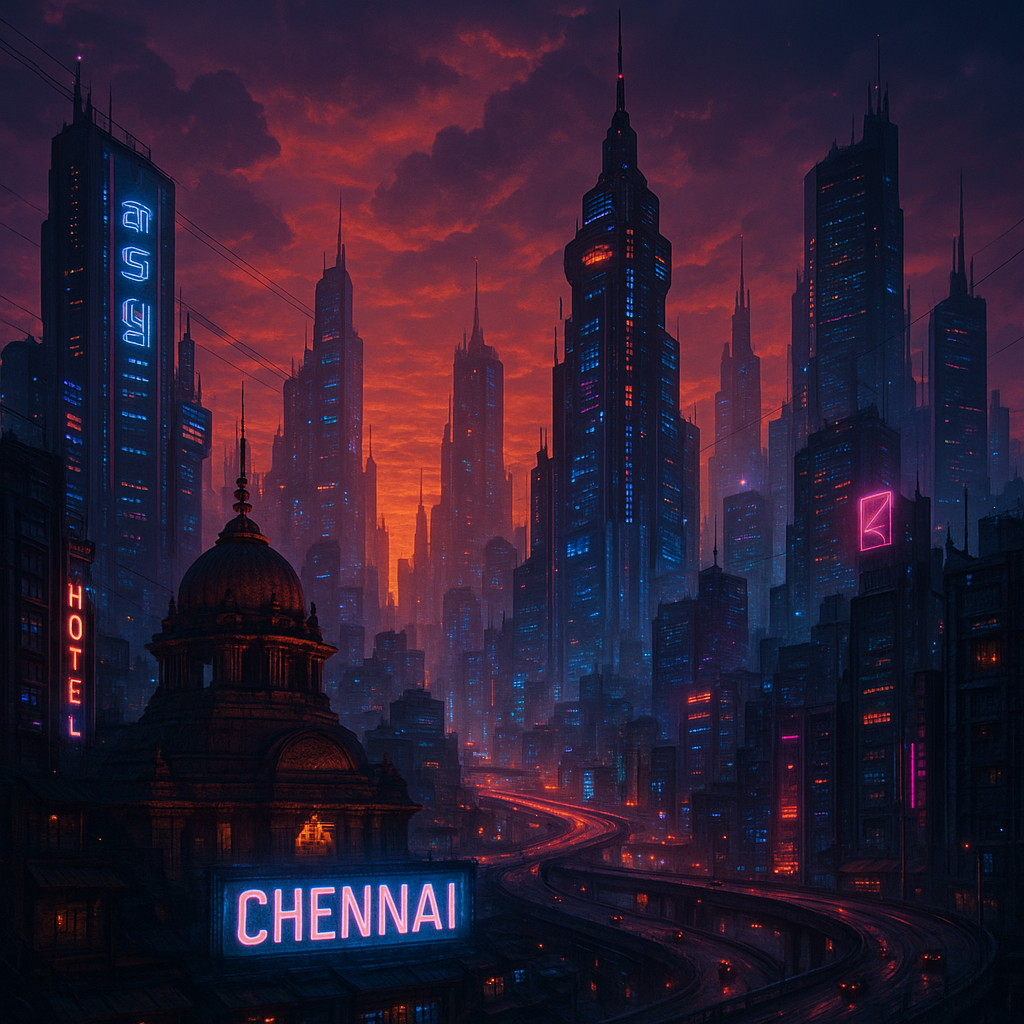

In [20]:
from IPython.display import Image, display

display(Image(filename="generated_image.png"))